In [211]:
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler
from skimage.metrics import structural_similarity as ssim
import matplotlib as mpl

import jax
import jax.numpy as jnp

from chromatix.ops import init_plane_resample
import chromatix.functional as cx

from pipeline import compute_fom #run_material_decomposition
from phantom import make_phantom, thresh_texture, make_db_vol, tmap_ellipsoid
from phantom import Material
from simulate import simulate_projection, apply_psf
from matdecomp import spbi_material_basis
from inputs.xscatter import get_wavelen, get_wavenum

import itertools
import pandas as pd
import seaborn as sns
from functools import lru_cache
import itertools as it

from matplotlib.ticker import FuncFormatter, MultipleLocator
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

def add_scalebar(ax, sz, Nx, real_dx, real_units, color='k', sv=1):
    width_px = sz * Nx 
    label = f'{real_dx * width_px:.0f} {real_units}'
    scalebar = AnchoredSizeBar(ax.transData, width_px, label, 'lower left', size_vertical=sv, frameon=False, color=color)
    ax.add_artist(scalebar)
    
adip = Material('adipose', 'H(11.2)C(61.9)N(1.7)O(25.1)', 0.93)
gland = Material('gland', 'H(10.2)C(18.4)N(3.2)O(67.6)', 1.04)
tissue = Material('tissue', 'H(10.2)C(14.3)N(3.4)O(70.8)Na(0.2)P(0.3)S(0.3)Cl(0.2)K(0.3)', 1.06)   
bone = Material('bone', 'H(3.4)C(15.5)N(4.2)O(43.5)Na(0.1)Mg(0.2)P(10.3)S(0.3)Ca(22.5)', 1.92)

In [8]:
def plot_all_imgs(result, mat1_name='gland', mat2_name='adipose', cmap='bwr', evals=None):
    """
    Show six panels in a row: low-E image, high-E image, BMI1, BMI2, GT1, GT2.
    Low/high energy images are grayscale with vmin=0, vmax=1.
    Two colorbars on the far right: one for thickness [cm] and one for normalized intensity.
    """
    # pull arrays
    imgs = result['imgs']          # shape [2, H, W]
    bmis = result['bmis']          # shape [2, H, W]
    gt_bmi1 = result['gt_bmi1']    # [H, W]
    gt_bmi2 = result['gt_bmi2']    # [H, W]

    # figure + axes
    fig, axes = plt.subplots(1, 6, figsize=(11.3, 2), constrained_layout=True)

    # --- intensity panels ---
    im_lo = axes[0].imshow(imgs[0], vmin=0, vmax=1, cmap='gray')
    im_hi = axes[1].imshow(imgs[1], vmin=0, vmax=1, cmap='gray')
    if evals is not None:
        axes[0].set_title(f'(a) {evals[0]:.0f}-keV image')
        axes[1].set_title(f'(b) {evals[1]:.0f}-keV image')

    # --- BMI / GT panels (thickness in cm) ---
    vmax_cm = 2e2 * max(gt_bmi1.max(), gt_bmi2.max())  # follow your previous scaling
    kw = {'vmin': 0, 'vmax': vmax_cm, 'cmap': cmap}

    im_b1 = axes[2].imshow(bmis[0]*1e2, **kw)
    im_b2 = axes[3].imshow(bmis[1]*1e2, **kw)
    im_g1 = axes[4].imshow(gt_bmi1*1e2, **kw)
    im_g2 = axes[5].imshow(gt_bmi2*1e2, **kw)

    axes[2].set_title(f'(c) {mat1_name} BMI', fontsize=9)
    axes[3].set_title(f'(d) {mat2_name} BMI', fontsize=9)
    axes[4].set_title(f'(e) {mat1_name} GT',  fontsize=9)
    axes[5].set_title(f'(f) {mat2_name} GT',  fontsize=9)

    for ax in axes:
        # ax.axis('off')
        ax.set_xticks([])
        ax.set_yticks([])
        
    # # --- colorbars on the far right ---
    # # place two slim colorbars to the right of the last panel
    # right_pos = axes[-1].get_position(fig)  # figure coords
    # bar_w = 0.01
    # gap = 0.11
    # # thickness bar closer to panels
    # cax_thk = fig.add_axes([right_pos.x1 + gap, right_pos.y0, bar_w, right_pos.height])
    # # intensity bar further right
    # cax_int = fig.add_axes([right_pos.x1 + gap + bar_w + 0.05, right_pos.y0, bar_w, right_pos.height])

    # cb_thk = fig.colorbar(im_g2, cax=cax_thk)
    # cb_thk.set_label('thickness [cm]', fontsize=9)
    # cb_thk.ax.tick_params(labelsize=8)

    # cb_int = fig.colorbar(im_hi, cax=cax_int)
    # cb_int.set_label('normalized intensity', fontsize=9)
    # cb_int.ax.tick_params(labelsize=8)
    fig.colorbar(im_b1, ax=axes, pad=0.01, label='thickness [cm]')

    plt.show()

# plot_all_imgs(results, evals=[15,20])


In [4]:
%%time


def plot_bmis(result, mat1_name='Material 1', mat2_name='Material 2', cmap='viridis'):
    """
    Plot BMIs and ground-truth thickness maps in a 4-column layout with parameter info in the figure title.
    
    Parameters
    ----------
    result : dict
        Output dictionary from run_material_decomposition.
        Must contain: 'bmis', 'gt_bmi1', 'gt_bmi2', and sweep parameters like
        'alpha', 'E1_keV', 'E2_keV', 'R_m', 'det_dx_m', 'thickness_m', 'mat_frac', 'I0_per_um2'.
    mat1_name, mat2_name : str
        Names for materials (used in titles).
    cmap : str
        Matplotlib colormap name.
    """
    bmis = result['bmis']
    gt_bmi1 = result['gt_bmi1']
    gt_bmi2 = result['gt_bmi2']

    # Build figure title from parameters (truncate decimals & scale units)
    title_str = (''
        # f"α={result.get('alpha', '?')}, "
        # f"E=({getf('E1_keV')},{getf('E2_keV')}) keV, "
        # f"R={getf('R_m', 1e3)} mm, "
        # f"Δx={getf('det_dx_m', 1e6)} µm, "
        # f"T={getf('thickness_m', 100)} cm, "
        # f"F={getf('mat_frac', 1.0, '{:.2f}')}, "
        # f"I0={getf('I0_per_um2', 1.0, '{:.1g}')} ph/µm²"
    )


    fig, axes = plt.subplots(1, 4, figsize=(8, 2.2), constrained_layout=True)
    fig.suptitle(title_str, fontsize=10)

    imgs = [bmis[0], bmis[1], gt_bmi1, gt_bmi2]
    titles = [f'BMI {mat1_name}', f'BMI {mat2_name}', f'GT {mat1_name}', f'GT {mat2_name}']
    kw = {'vmin':0, 'vmax':2e2*max(gt_bmi1.max(), gt_bmi2.max()), 'cmap':cmap}  # cm
    
    for ax, img, title in zip(axes, imgs, titles):
        im = ax.imshow(img*1e2, **kw)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
        # cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        # cbar.ax.tick_params(labelsize=8)
    fig.colorbar(im, ax=axes, pad=0.01, label='thickness [cm]')
    
    plt.show()

# plot_bmis(res, mat1_name='Gland', mat2_name='Adipose', cmap='bwr')


CPU times: user 3 μs, sys: 3 μs, total: 6 μs
Wall time: 12.2 μs


In [5]:
custom_cycler = cycler('color', ['#0072B2', '#009E73', '#F0E442', '#D55E00', '#CC79A7'])  # color blind

plt.rcParams.update({
    'figure.dpi': 300,
    'font.size':10,
    'axes.titlesize':10,
    'axes.labelsize':8,
    'axes.linewidth': .5,
    'axes.prop_cycle': custom_cycler,
    'xtick.top': True, 
    'ytick.right': True, 
    'xtick.direction': 'in', 
    'ytick.direction': 'in',
    'xtick.labelsize':8,
    'ytick.labelsize':8,
    'legend.fontsize': 8,
    'lines.linewidth':1,
    'image.cmap':'gray',
    'text.usetex': True,
    'font.family': 'serif'
})

FOM: 40.643 Fgt: 0.526 Fmd: 0.739 SSIM1: 0.486 SSIM2: 0.413


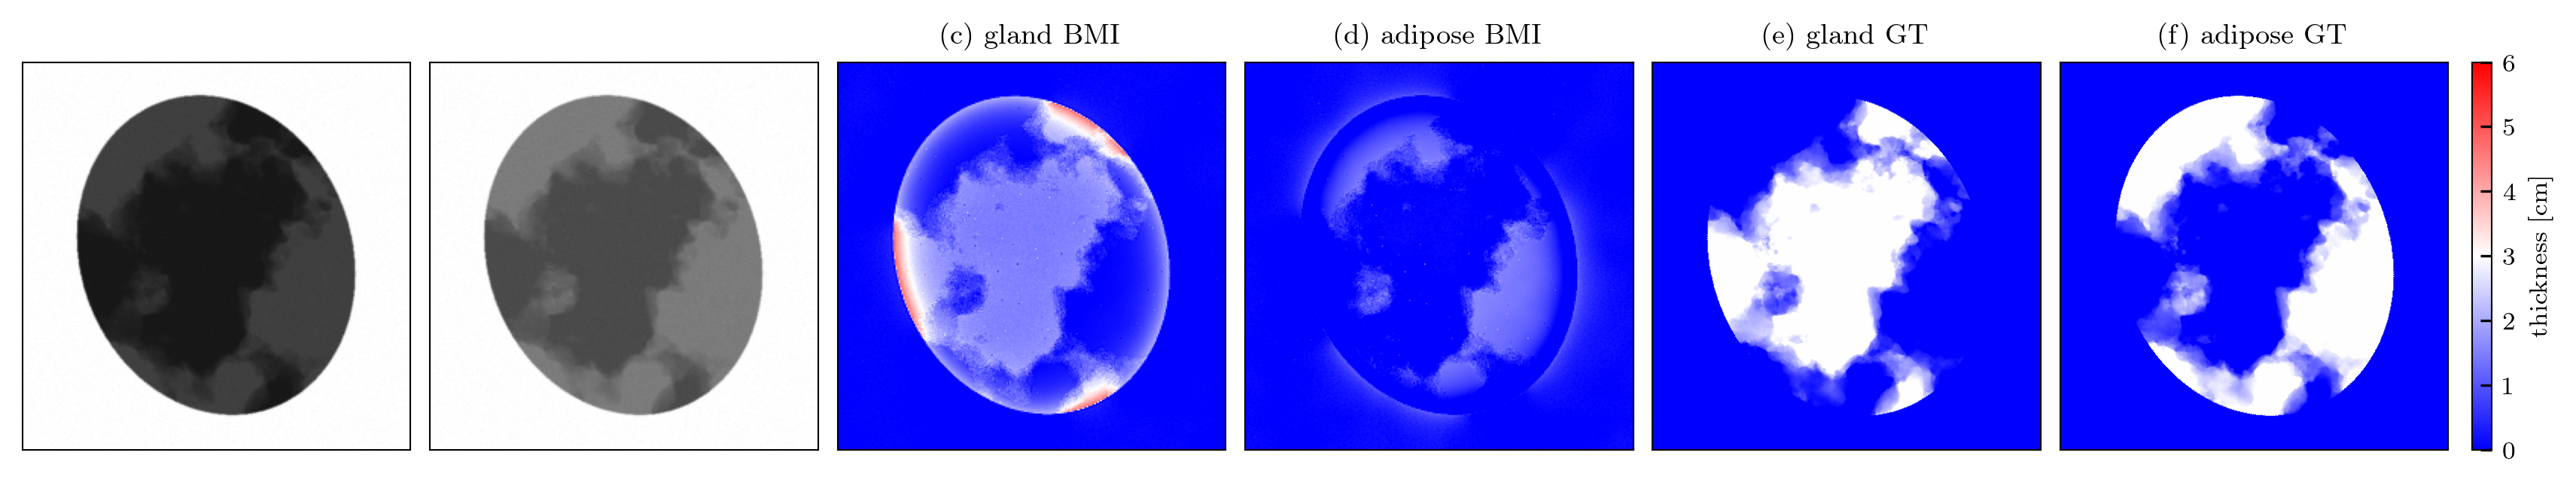

CPU times: user 4.98 s, sys: 160 ms, total: 5.14 s
Wall time: 803 ms


In [105]:
%%time

# testing!
seed = 422
np.random.seed(seed)

N = 512
dx = 5e-6
Nz = 50  
px, py = 0.35, 0.42  #0.32, 0.4

struct = np.zeros([N, N])
struct[tmap_ellipsoid(N, px*N, py*N, angle=20) > 1e-3] = 1


alpha = 5
# vol = make_phantom(N, dx, alpha=alpha)[:Nz]

def run_material_decomposition(energies, R, det_dx, mat_frac=0.2, thickness=0.01, I0=1e5, mat1=gland, mat2=adip, struct=struct, vol=vol):
    mat_dict = {0: mat1, 1: mat2}
    
    Nz = vol.shape[0]
    N = vol.shape[1]

    dz = thickness / Nz
    det_N = int(dx * N // det_dx)

    # np.random.seed(seed)
    
    det_struct = np.zeros([det_N, det_N]) 
    det_struct[tmap_ellipsoid(det_N, px*det_N, py*det_N, angle=20) > 1e-3] = 1

    # vol = make_phantom(N, dx, alpha=alpha)[:Nz]
    vol_mask = thresh_texture(vol, 1-mat_frac)   # mat_frac is actually for mat2? oops

    imgs = []
    for energy in energies:
        vol_delta, vol_beta = make_db_vol(vol_mask, mat_dict, energy)
        proj_delta = dz * struct * np.sum(vol_delta[0], axis=0)
        proj_beta = dz * struct * np.sum(vol_beta[0], axis=0)

        img = simulate_projection(
            proj_beta, proj_delta, dx, det_N, det_dx, energy, R,
            I0=I0, #det_psf=None, 
            det_psf='gaussian', det_fwhm=5e-6
        )
        imgs.append(img)

    imgs = np.nan_to_num(np.array(imgs)).clip(0, None) # ** 0.5

    ds1, bs1 = mat1.db(energies)
    ds2, bs2 = mat2.db(energies)
    ds = -np.array([ds1, ds2])
    mus = 4 * np.array([bs1, bs2]) * get_wavenum(energies)

    bmis = spbi_material_basis(imgs, R, det_dx, ds.T, mus.T)
    bmis = np.nan_to_num(bmis.clip(0, 2*thickness))
    
    # apply struct to bmis
    # bmis = np.array([bmis[0]*det_struct, bmis[1]*det_struct])

    gt_bmi1 = dz * struct * np.sum(vol_mask == 0, axis=0)
    gt_bmi2 = dz * struct * np.sum(vol_mask == 1, axis=0)

    
    # figure of merit + SSIM
    fom, Fgt, Fmd = compute_fom(gt_bmi1, gt_bmi2, bmis)

    det_resample_func = init_plane_resample(img.shape, (det_dx, det_dx), resampling_method='linear')
    gt_bmi1_resampled = det_resample_func(gt_bmi1[..., None, None],  np.array([dx]))[..., 0, 0]
    gt_bmi2_resampled = det_resample_func(gt_bmi2[..., None, None],  np.array([dx]))[..., 0, 0]
    
    ssim1 = ssim(bmis[0], gt_bmi1_resampled, data_range=2*thickness)
    ssim2 = ssim(bmis[1], gt_bmi2_resampled, data_range=2*thickness)

    return {
        'fom': fom,
        'Fgt': Fgt,
        'Fmd': Fmd,
        'imgs': imgs,
        'bmis': bmis,
        'gt_bmi1': gt_bmi1,
        'gt_bmi2': gt_bmi2,
        'ssim1': ssim1,
        'ssim2': ssim2
    }

det_dx = 10e-6

for TT in [3e-2]:
    for propdist in [500e-3]: #np.arange(0, 100, 10)*1e-3:
        results = run_material_decomposition(
            (20, 25),
            R = propdist,
            det_dx = det_dx,
            thickness = TT,
            I0 = 1e2,
            mat_frac=0.4
        )
    
        print(
            f"FOM: {results['fom']:.3f} "
            f"Fgt: {results['Fgt']:.3f} "
            f"Fmd: {results['Fmd']:.3f} "
            f"SSIM1: {results['ssim1']:.3f} "
            f"SSIM2: {results['ssim2']:.3f}"
        )

        plot_all_imgs(results)


# fig 1 - effect of PBI

In [123]:
%%time

# # FIXED

I0 = 1e2    
dx = 5e-6
N = 512
Nz = 50  
px, py = 0.35, 0.42 
alpha = 5
thickness = 3e-2
energies = (20, 25)
det_dx = 10e-6


# VARS
Rs        = np.arange(0, 105, 10) * 1e-3
mat_fracs = np.arange(0.2, 0.61, 0.1)
seeds =  np.arange(3, 13).astype(int)


# RUN
struct = np.zeros([N, N])
struct[tmap_ellipsoid(N, px*N, py*N, angle=20) > 1e-3] = 1

results = []
for seed in seeds:

    np.random.seed(seed)
    vol = make_phantom(N, dx, alpha=alpha)[:Nz]
    
    print()
    print(seed, np.sum(vol))   # print as a visible check that the vol changes
    
    for mat_frac in mat_fracs:
        print(seed, mat_frac)
        
        for R in Rs:   
            res = run_material_decomposition(
                vol=vol,  #  pass the vol !!
                energies=energies,
                R=R,
                det_dx=det_dx,
                thickness=thickness,
                mat_frac=mat_frac,   # leave other args at defaults or add here
            )
            results.append({
                'seed': int(seed),
                'alpha': int(alpha),
                'E1_keV': float(energies[0]),
                'E2_keV': float(energies[1]),
                'R_m': float(R),
                'det_dx_m': float(det_dx),
                'thickness_m': float(thickness),
                'mat_frac': float(mat_frac),
                **res,   # includes Fgt, Fmd, fom, etc.
            })
    
# optional: quick count
print(f'total runs: {len(results)}')

df = pd.DataFrame(results)
df.to_csv('fom_sweep_fig1.csv', index=False)



3 9435599.936557654
3 0.2


/Users/gjad/Documents/Workspace/xpc-mammo/.venv/lib/python3.12/site-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype <class 'numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


3 0.30000000000000004
3 0.4000000000000001
3 0.5000000000000001
3 0.6000000000000001

4 7823874.3372365525
4 0.2
4 0.30000000000000004
4 0.4000000000000001
4 0.5000000000000001
4 0.6000000000000001

5 9881901.545331098
5 0.2
5 0.30000000000000004
5 0.4000000000000001
5 0.5000000000000001
5 0.6000000000000001

6 9883892.6139901
6 0.2
6 0.30000000000000004
6 0.4000000000000001
6 0.5000000000000001
6 0.6000000000000001

7 8520438.090781184
7 0.2
7 0.30000000000000004
7 0.4000000000000001
7 0.5000000000000001
7 0.6000000000000001

8 9190284.304893509
8 0.2
8 0.30000000000000004
8 0.4000000000000001
8 0.5000000000000001
8 0.6000000000000001

9 9649418.800977118
9 0.2
9 0.30000000000000004
9 0.4000000000000001
9 0.5000000000000001
9 0.6000000000000001

10 8755268.281857044
10 0.2
10 0.30000000000000004
10 0.4000000000000001
10 0.5000000000000001
10 0.6000000000000001

11 9733896.011156704
11 0.2
11 0.30000000000000004
11 0.4000000000000001
11 0.5000000000000001
11 0.6000000000000001

12 8563

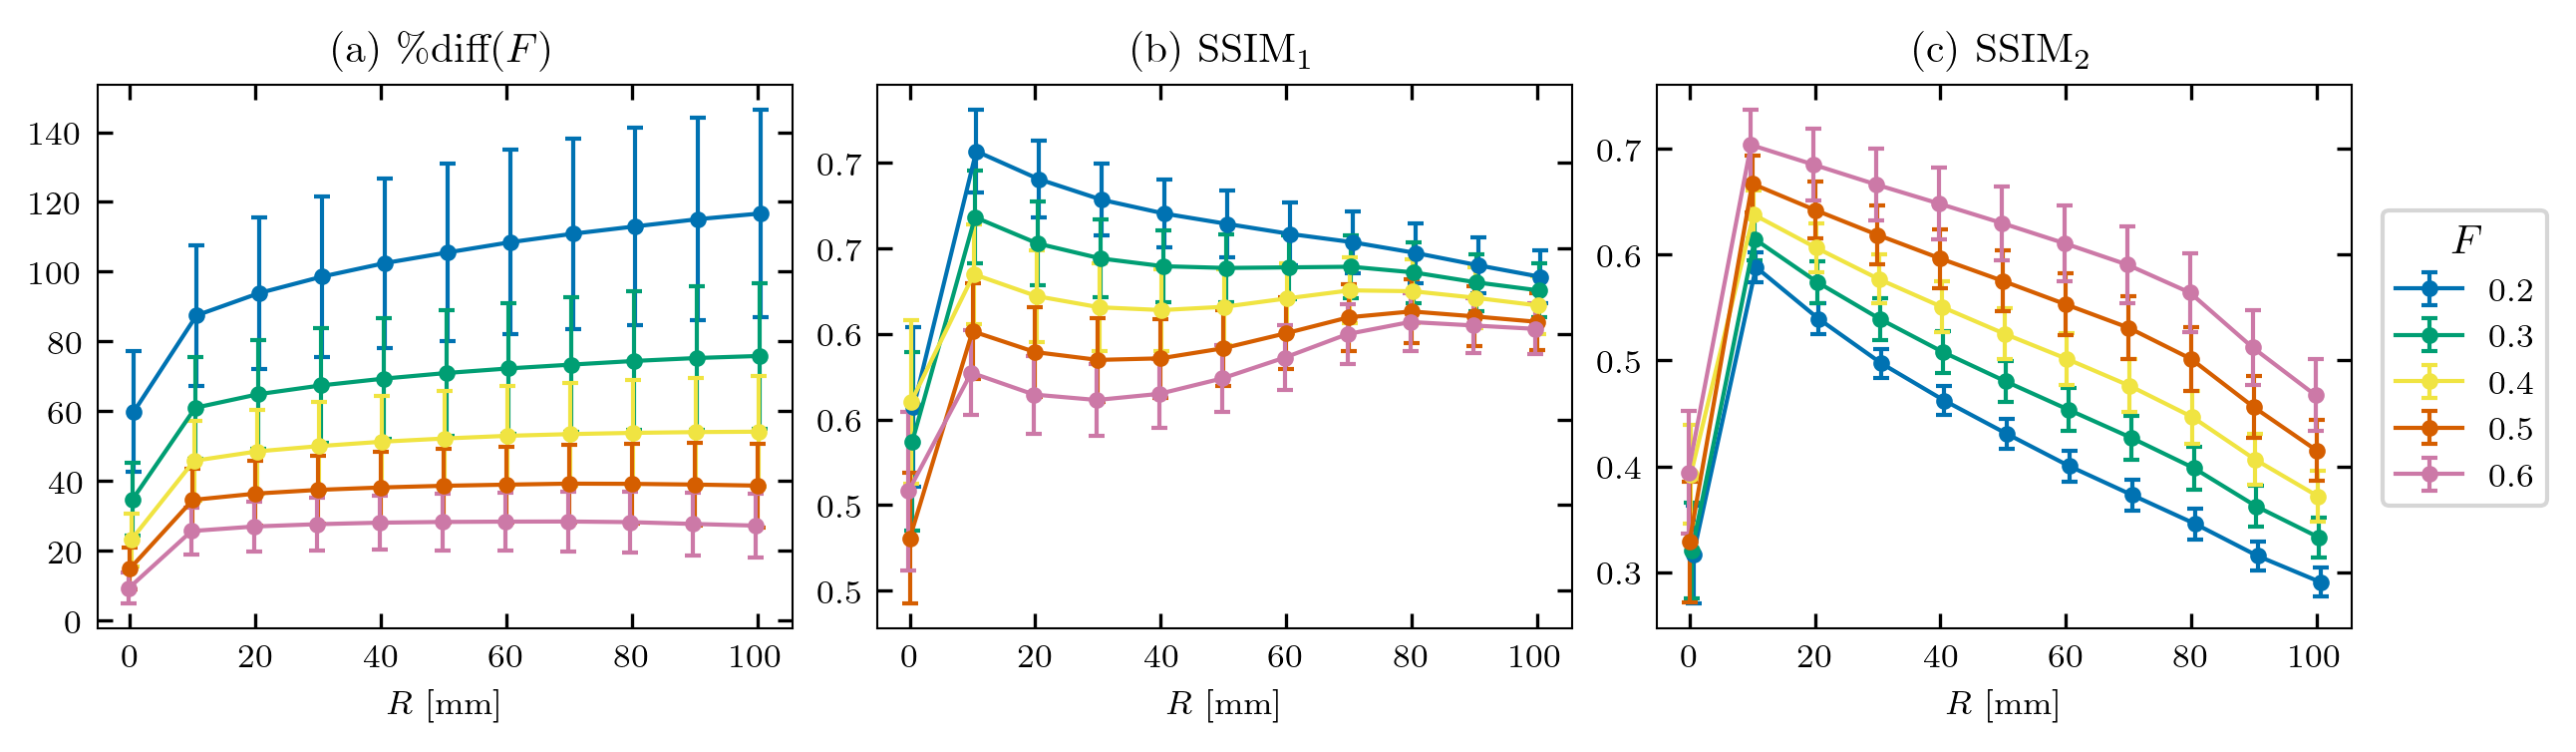

CPU times: user 391 ms, sys: 401 ms, total: 792 ms
Wall time: 1.45 s


In [168]:
%%time

# Compute mean and std across seeds for each (mat_frac, R_m)
stats = (
    df.groupby(['mat_frac', 'R_m'])
      .agg(fom_mean=('fom', 'mean'),
           fom_std =('fom', 'std'),
           ssim1_mean=('ssim1', 'mean'),
           ssim1_std =('ssim1', 'std'),
           ssim2_mean=('ssim2', 'mean'),
           ssim2_std =('ssim2', 'std'))
      .reset_index()
)

metrics = [
    ('fom_mean',  'fom_std',  r'(a) \%diff($F$) '),
    ('ssim1_mean','ssim1_std',r'(b) SSIM$_1$'),
    ('ssim2_mean','ssim2_std',r'(c) SSIM$_2$'),
]

fig, axes = plt.subplots(1, 3, figsize=(8.5, 2.4), sharex=True, layout='constrained')
mat_fracs = sorted(stats['mat_frac'].unique())

for ax, (mean_col, std_col, title) in zip(axes, metrics):
    for mf in mat_fracs:
        sub = stats[stats['mat_frac'] == mf].sort_values('R_m')
        x = 1e3 * sub['R_m'].values + (1 - 2*mf)
        y = sub[mean_col].values
        yerr = np.nan_to_num(sub[std_col].values, nan=0.0)
        ax.errorbar(x, y, yerr=yerr/2, capsize=2, marker='.', linestyle='-', lw=1, label=f'{mf:.1f}', alpha=1)
    ax.set_title(title)
    ax.set_xlabel('$R$ [mm]')
    # ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.1f}'.rstrip('0').rstrip('.')))

axes[-1].legend(title='$F$', bbox_to_anchor=(1.02, 0.8), loc='upper left')

plt.savefig('spie2026_mammo/fig1_pbi.pdf', bbox_inches='tight')
plt.show()


In [193]:
# --- Print mean ± stdev for Fgt and Fmd for each mat_frac ---

# add to table? TODO: re-bin based on the resulting mat frac
for mf in mat_fracs:
    raw = df[df['mat_frac'] == mf]
    fgt_mean, fgt_std = raw['Fgt'].mean(), raw['Fgt'].std()
    fmd_mean, fmd_std = raw['Fmd'].mean(), raw['Fmd'].std()
    print(f'mat_frac {mf:.1f}: Fgt = {fgt_mean:.3f} ± {fgt_std:.3f}, Fmd = {fmd_mean:.3f} ± {fmd_std:.3f}')


mat_frac 0.2: Fgt = 0.214 ± 0.083, Fmd = 0.394 ± 0.076
mat_frac 0.3: Fgt = 0.305 ± 0.105, Fmd = 0.478 ± 0.093
mat_frac 0.4: Fgt = 0.391 ± 0.125, Fmd = 0.552 ± 0.106
mat_frac 0.5: Fgt = 0.479 ± 0.141, Fmd = 0.624 ± 0.114
mat_frac 0.6: Fgt = 0.568 ± 0.148, Fmd = 0.694 ± 0.114


<timed exec>:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


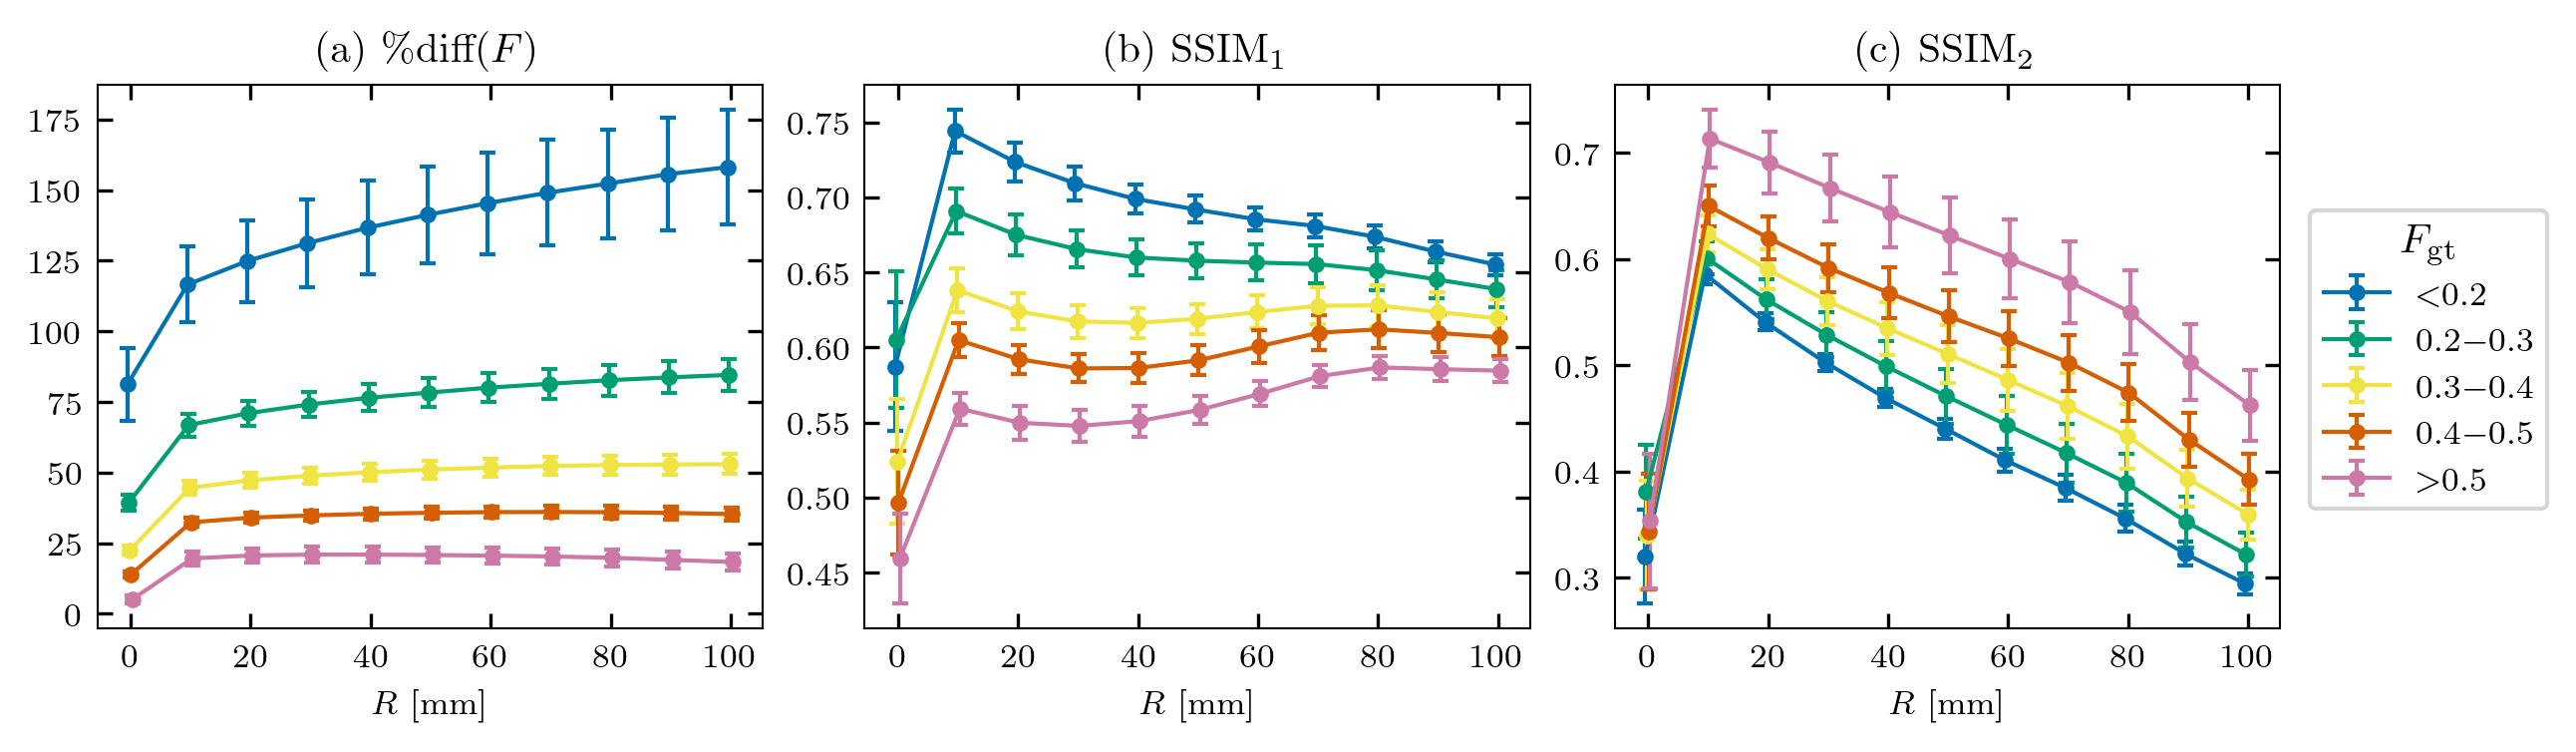

CPU times: user 410 ms, sys: 22.2 ms, total: 432 ms
Wall time: 451 ms


In [275]:
%%time

# re-binned version 
df = pd.read_csv('fom_sweep_fig1.csv')

# Bin Fgt into categories
bin_edges   = [-np.inf, 0.2, 0.3, 0.4, 0.5, np.inf]  
bin_labels  = [r'$<$0.2', '0.2$-$0.3', '0.3$-$0.4', '0.4$-$0.5', r'$>$0.5'] #'0.5-0.6', '>0.6']
cat_type    = pd.api.types.CategoricalDtype(categories=bin_labels, ordered=True)
df = df.copy()
df['Fgt_bin'] = pd.cut(df['Fgt'], bins=bin_edges, labels=bin_labels, right=False, include_lowest=True).astype(cat_type)

# Compute mean and std across seeds for each (Fgt_bin, R_m)
stats = (
    df.dropna(subset=['Fgt_bin'])
      .groupby(['Fgt_bin', 'R_m'])
      .agg(fom_mean=('fom', 'mean'),
           fom_std =('fom', 'std'),
           ssim1_mean=('ssim1', 'mean'),
           ssim1_std =('ssim1', 'std'),
           ssim2_mean=('ssim2', 'mean'),
           ssim2_std =('ssim2', 'std'))
      .reset_index()
)

metrics = [
    ('fom_mean',  'fom_std',  r'(a) \%diff($F$) '),
    ('ssim1_mean','ssim1_std',r'(b) SSIM$_1$'),
    ('ssim2_mean','ssim2_std',r'(c) SSIM$_2$'),
]

# Small, fixed jitter per Fgt bin (in mm)
offset_map_mm = {
    r'$<$0.2':  -0.50,
    '0.2$-$0.3': -0.30,
    '0.3$-$0.4': -0.10,
    '0.4$-$0.5':  0.10,
    r'$>$0.5':  0.30,
    # '0.5-0.6':  0.30,
    # '>0.6':    0.50,
}

fig, axes = plt.subplots(1, 3, figsize=(8.5, 2.4), sharex=True, layout='constrained')

# Only plot bins that are present
bins_present = [lab for lab in bin_labels if (stats['Fgt_bin'] == lab).any()]

for ax, (mean_col, std_col, title) in zip(axes, metrics):
    for lab in bins_present:
        sub = stats[stats['Fgt_bin'] == lab].sort_values('R_m')
        x_mm = 1e3 * sub['R_m'].values + offset_map_mm[lab]   # jittered in mm
        y    = sub[mean_col].values
        yerr = np.nan_to_num(sub[std_col].values, nan=0.0)
        ax.errorbar(x_mm, y, yerr=yerr/2, capsize=2, marker='.', linestyle='-', lw=1,
                    label=lab, alpha=1)
    ax.set_title(title)
    ax.set_xlabel(r'$R$ [mm]')
    # ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.1f}'.rstrip('0').rstrip('.')))

axes[-1].legend(title=r'$F_{\mathrm{gt}}$', bbox_to_anchor=(1.02, 0.8), loc='upper left')

plt.savefig('spie2026_mammo/fig1_v2_pbi.pdf', bbox_inches='tight')
plt.show()


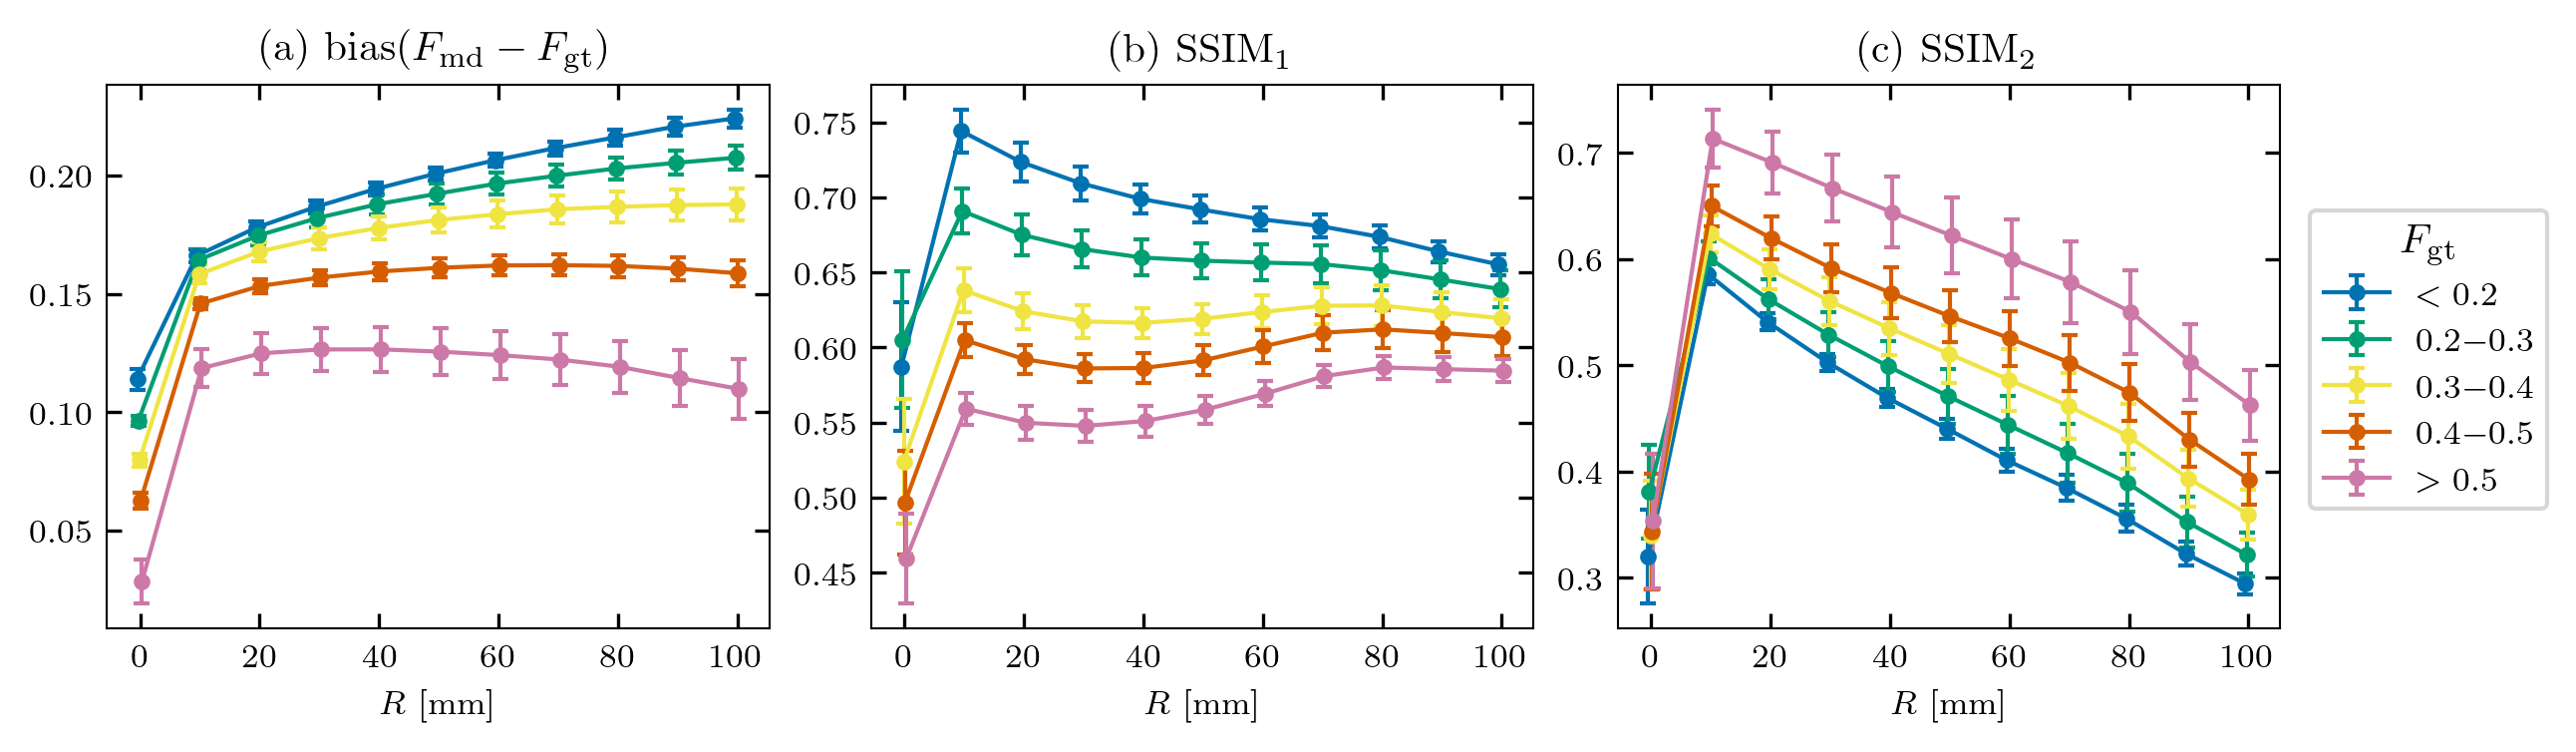

CPU times: user 410 ms, sys: 17.7 ms, total: 428 ms
Wall time: 447 ms


In [277]:
%%time

# re-binned version 
df = pd.read_csv('fom_sweep_fig1.csv')

# Bin Fgt into categories
bin_edges   = [-np.inf, 0.2, 0.3, 0.4, 0.5, np.inf]
bin_labels  = [r'$<0.2$', '0.2$-$0.3', '0.3$-$0.4', '0.4$-$0.5', r'$>0.5$']
cat_type    = pd.api.types.CategoricalDtype(categories=bin_labels, ordered=True)
df = df.copy()
df['Fgt_bin'] = pd.cut(df['Fgt'], bins=bin_edges, labels=bin_labels, right=False, include_lowest=True).astype(cat_type)

# --- NEW: bias ---
df['bias'] = df['Fmd'] - df['Fgt']

# Compute mean and std across seeds for each (Fgt_bin, R_m)
stats = (
    df.dropna(subset=['Fgt_bin'])
      .groupby(['Fgt_bin', 'R_m'], observed=True)
      .agg(
           bias_mean =('bias',  'mean'),
           bias_std  =('bias',  'std'),
           ssim1_mean=('ssim1', 'mean'),
           ssim1_std =('ssim1', 'std'),
           ssim2_mean=('ssim2', 'mean'),
           ssim2_std =('ssim2', 'std'))
      .reset_index()
)

# Use bias for panel (a), SSIM1 for (b), SSIM2 for (c)
metrics = [
    ('bias_mean',  'bias_std',  r'(a) bias($F_{\mathrm{md}}-F_{\mathrm{gt}}$)'),
    ('ssim1_mean','ssim1_std', r'(b) SSIM$_1$'),
    ('ssim2_mean','ssim2_std', r'(c) SSIM$_2$'),
]

# Small, fixed jitter per Fgt bin (in mm)
offset_map_mm = {
    r'$<0.2$':   -0.50,
    '0.2$-$0.3': -0.30,
    '0.3$-$0.4': -0.10,
    '0.4$-$0.5':  0.10,
    r'$>0.5$':    0.30,
}

fig, axes = plt.subplots(1, 3, figsize=(8.5, 2.4), sharex=True, layout='constrained')

# Only plot bins that are present
bins_present = [lab for lab in bin_labels if (stats['Fgt_bin'] == lab).any()]

for ax, (mean_col, std_col, title) in zip(axes, metrics):
    for lab in bins_present:
        sub = stats[stats['Fgt_bin'] == lab].sort_values('R_m')
        x_mm = 1e3 * sub['R_m'].values + offset_map_mm[lab]   # jittered in mm
        y    = sub[mean_col].values
        yerr = np.nan_to_num(sub[std_col].values, nan=0.0)
        ax.errorbar(x_mm, y, yerr=yerr/2, capsize=2, marker='.', linestyle='-', lw=1,
                    label=lab, alpha=1)
    ax.set_title(title)
    ax.set_xlabel(r'$R$ [mm]')
    # ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.1f}'.rstrip('0').rstrip('.')))

axes[-1].legend(title=r'$F_{\mathrm{gt}}$', bbox_to_anchor=(1.02, 0.8), loc='upper left')

plt.savefig('spie2026_mammo/fig1_v3_pbi.pdf', bbox_inches='tight')
plt.show()


In [273]:
# --- Print mean ± stdev for Fgt and Fmd for each Fgt_bin ---

# ensure Fgt is binned (skip if you've already created df['Fgt_bin'])
if 'Fgt_bin' not in df.columns:
    bin_edges  = [-np.inf, 0.2, 0.3, 0.4, 0.5, 0.6, np.inf]
    bin_labels = ['<0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', '0.5-0.6', '>0.6']
    cat_type   = pd.api.types.CategoricalDtype(categories=bin_labels, ordered=True)
    df['Fgt_bin'] = pd.cut(df['Fgt'], bins=bin_edges, labels=bin_labels, right=False, include_lowest=True).astype(cat_type)

bins_present = [lab for lab in df['Fgt_bin'].cat.categories if (df['Fgt_bin'] == lab).any()]

print('# --- mean ± stdev for Fgt and Fmd for each Fgt_bin ---')
for lab in bins_present:
    raw = df[df['Fgt_bin'] == lab]
    n = len(raw) // 11
    fgt_mean, fgt_std = raw['Fgt'].mean(), raw['Fgt'].std()
    fmd_mean, fmd_std = raw['Fmd'].mean(), raw['Fmd'].std()
    bias = (raw['Fmd'] - raw['Fgt']).mean()
    print(f'True F bin {lab:>10}: n = {n:2d} | Fgt = {fgt_mean:.3f} ± {fgt_std:.3f} | '
          f'Fmd = {fmd_mean:.3f} ± {fmd_std:.3f} | bias(Fmd−Fgt) = {bias:+.3f}')


# --- mean ± stdev for Fgt and Fmd for each Fgt_bin ---
True F bin     $<$0.2: n =  7 | Fgt = 0.149 ± 0.031 | Fmd = 0.342 ± 0.043 | bias(Fmd−Fgt) = +0.193
True F bin  0.2$-$0.3: n = 11 | Fgt = 0.248 ± 0.023 | Fmd = 0.431 ± 0.038 | bias(Fmd−Fgt) = +0.183
True F bin  0.3$-$0.4: n = 11 | Fgt = 0.357 ± 0.026 | Fmd = 0.527 ± 0.037 | bias(Fmd−Fgt) = +0.170
True F bin  0.4$-$0.5: n =  7 | Fgt = 0.453 ± 0.028 | Fmd = 0.602 ± 0.036 | bias(Fmd−Fgt) = +0.149
True F bin     $>$0.5: n = 14 | Fgt = 0.622 ± 0.076 | Fmd = 0.734 ± 0.064 | bias(Fmd−Fgt) = +0.113


# fig 2 - utility of phase for different breast types (thickness, alpha, F)

In [210]:

I0 = 1e2    
dx = 5e-6
N = 512
Nz = 50  
px, py = 0.35, 0.42 
energies = (20, 25)
det_dx = 10e-6
seed = 422

# VARS
Rs        = np.array([0, 50]) * 1e-3      # panel columns 
thicknesses = np.array([1, 2, 3]) * 1e-2  # panel rows
alphas    = np.arange(3.0, 6.1, 0.5)      # y-axis
mat_fracs = np.arange(0.2, 0.81, 0.1)     # x-axis 


# RUN
struct = np.zeros([N, N])
struct[tmap_ellipsoid(N, px*N, py*N, angle=20) > 1e-3] = 1

results = []

for alpha in alphas:
    
    np.random.seed(seed)
    vol = make_phantom(N, dx, alpha=alpha)[:Nz]
    print()
    print(seed, np.sum(vol))   # print as a visible check that the vol changes
    
    for mat_frac in mat_fracs:
        for R in Rs:
            for thickness in thicknesses:
        
                res = run_material_decomposition(
                    vol=vol,
                    energies=energies,
                    R=R,
                    det_dx=det_dx,
                    thickness=thickness,
                    mat_frac=mat_frac,   # leave other args at defaults or add here
                )
                results.append({
                    'seed': int(seed),
                    'alpha': int(alpha),
                    'E1_keV': float(energies[0]),
                    'E2_keV': float(energies[1]),
                    'R_m': float(R),
                    'det_dx_m': float(det_dx),
                    'thickness_m': float(thickness),
                    'mat_frac': float(mat_frac),
                    **res,   # includes Fgt, Fmd, fom, etc.
                })
        
# optional: quick count
print(f'total runs: {len(results)}')

df = pd.DataFrame(results)
df.to_csv('fom_sweep_fig2.csv', index=False)



422 3006524.9731807904

422 4249593.519572701

422 6096946.93055507

422 7809843.643799458

422 9150243.928101774

422 10143392.690376513

422 10887655.510603309
total runs: 294


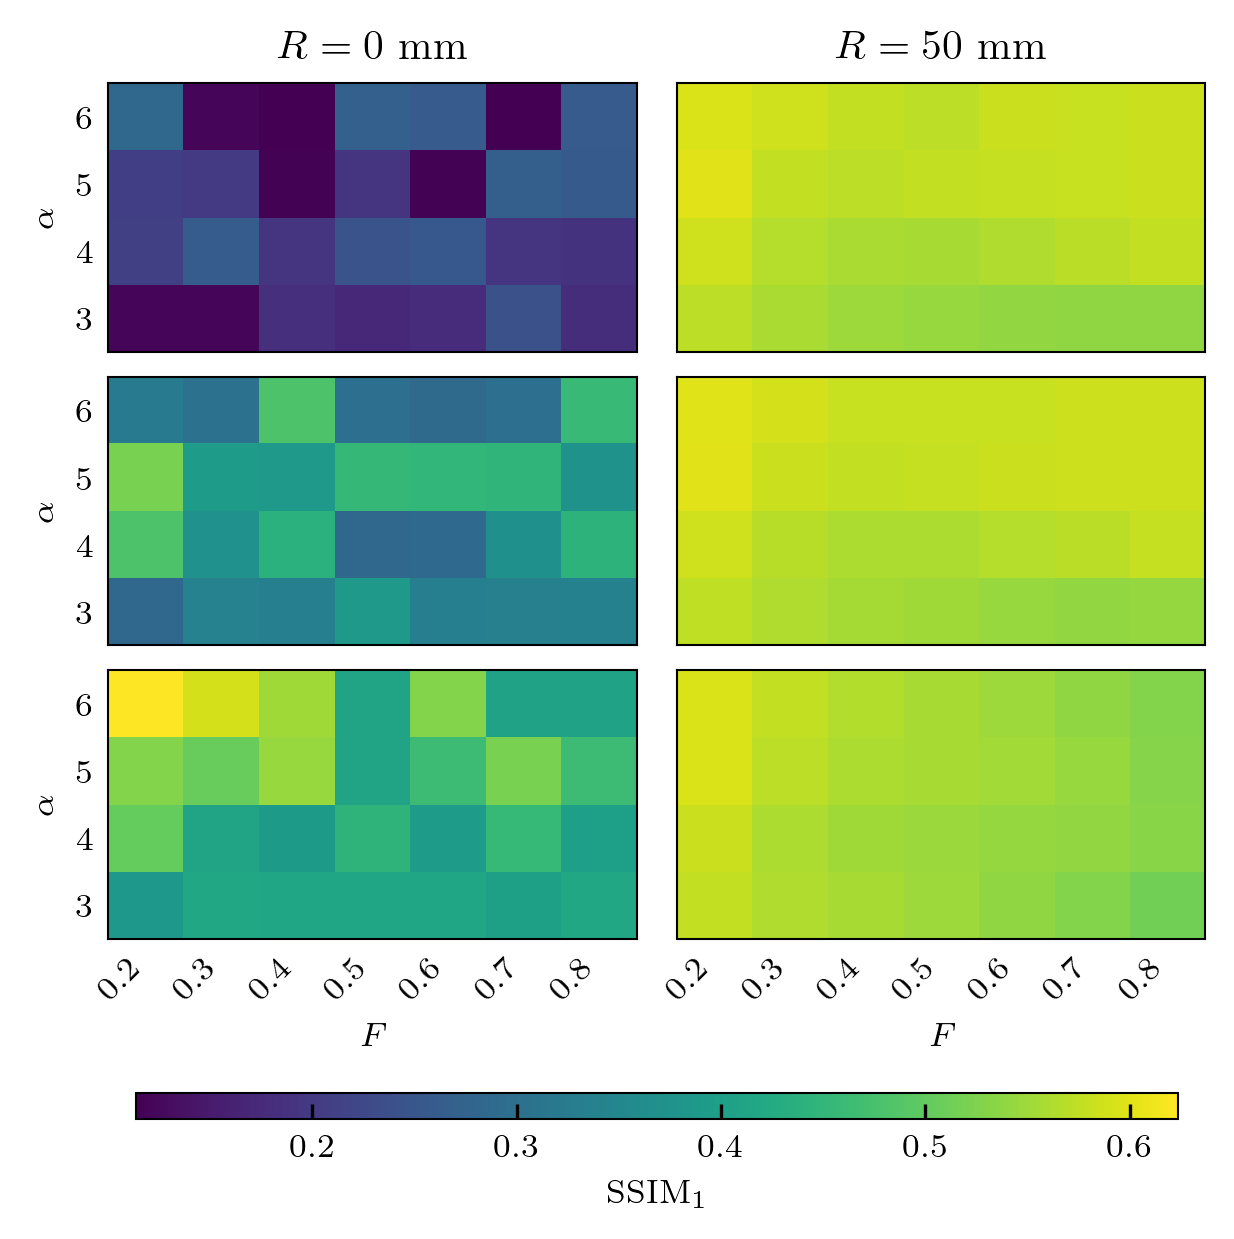

CPU times: user 192 ms, sys: 6.02 ms, total: 198 ms
Wall time: 201 ms


In [227]:
%%time
# --- aggregate SSIM1 over seeds/replicates for each (R, thickness, alpha, mat_frac) ---
stats = (
    df.groupby(['R_m', 'thickness_m', 'alpha', 'mat_frac'], observed=True)
      .agg(ssim1_mean=('ssim1', 'mean'))
      .reset_index()
)

Rs          = np.sort(stats['R_m'].unique())
thicknesses = np.sort(stats['thickness_m'].unique())

nrows, ncols = len(thicknesses), len(Rs)
# fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 2.8*nrows), constrained_layout=True, sharey=True, sharex=True)
fig, axes = plt.subplots(nrows, ncols, figsize=(4,4), constrained_layout=True, sharey=True, sharex=True)

# consistent color scale across panels
vmin = float(stats['ssim1_mean'].min())
vmax = float(stats['ssim1_mean'].max())

import matplotlib as mpl
cmap = mpl.cm.viridis.copy()
cmap.set_bad(color='#dddddd')  # show missing cells as light gray

def _ax_at(i, j):
    if nrows > 1 and ncols > 1: return axes[i, j]
    if nrows == 1 and ncols > 1: return axes[j]
    if nrows > 1 and ncols == 1: return axes[i]
    return axes  # 1x1

last_im = None
for i, T in enumerate(thicknesses):
    for j, R in enumerate(Rs):
        ax = _ax_at(i, j)
        sub = stats[(stats['R_m'] == R) & (stats['thickness_m'] == T)]

        # axes for this panel
        alphas    = np.sort(sub['alpha'].unique())
        mat_fracs = np.sort(sub['mat_frac'].unique())

        # pivot to 2D (rows=alpha, cols=mat_frac)
        pivot = (sub.pivot_table(index='alpha', columns='mat_frac', values='ssim1_mean')
                    .reindex(index=alphas, columns=mat_fracs))

        data = np.ma.masked_invalid(pivot.to_numpy())
        im = ax.imshow(data, origin='lower', aspect='auto', vmin=vmin, vmax=vmax, cmap=cmap)
        last_im = im

        # cosmetics
        if i == 0:
            ax.set_title(fr'$R={R*1e3:.0f}\ \mathrm{{mm}}$')
        if j == 0:
            ax.set_ylabel(r'$\alpha$')#+f'$T$ = {T*1e2:.0f} cm')

        # ticks/labels
        ax.set_xticks(np.arange(len(mat_fracs)))
        ax.set_xticklabels([f'{m:.1f}'.rstrip('0').rstrip('.') for m in mat_fracs], rotation=45, ha='right')
        ax.set_yticks(np.arange(len(alphas)))
        ax.set_yticklabels([f'{a:.2f}'.rstrip('0').rstrip('.') for a in alphas])
    
        ax.tick_params(axis='both', which='both', length=0)#, width=0.8)

# shared colorbar
cbar_axes = axes.ravel().tolist() if (nrows*ncols > 1) else [axes]
cb = fig.colorbar(last_im, ax=cbar_axes, orientation='horizontal', pad=0.04, shrink=0.95, aspect=40)
# cb = fig.colorbar(last_im, ax=axes.ravel().tolist() if (nrows*ncols > 1) else [axes], shrink=0.95, pad=0.02)
cb.set_label(r'SSIM$_1$')

# axis label for x on bottom row only
for j in range(ncols):
    ax = _ax_at(nrows-1, j)
    ax.set_xlabel(r'$F$')

plt.show()


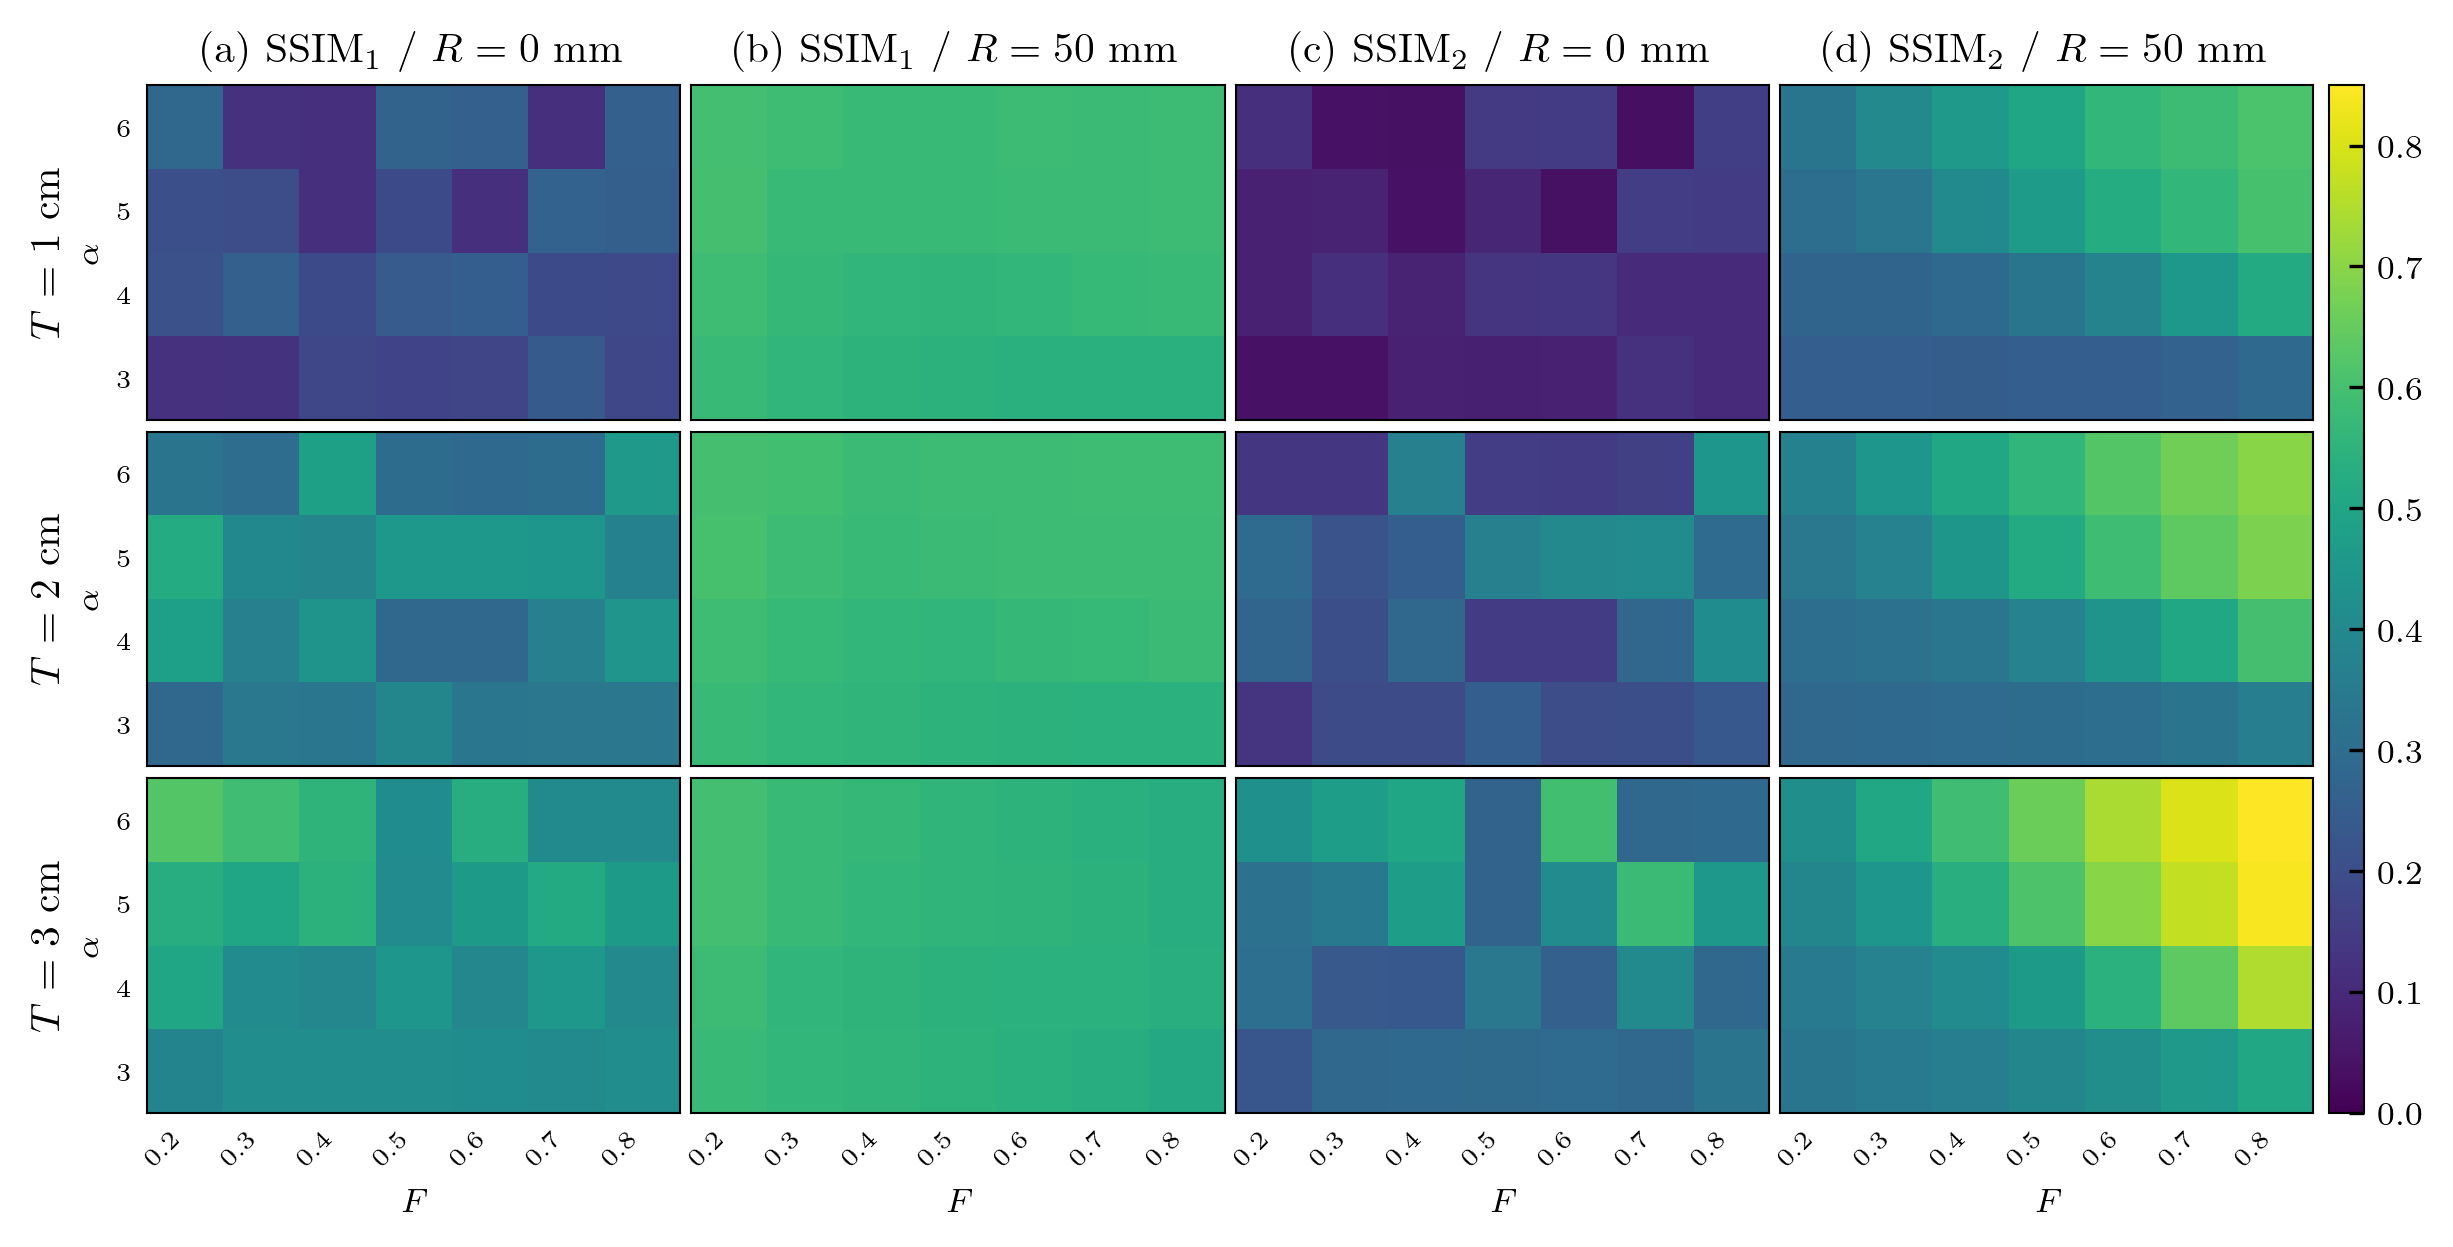

CPU times: user 736 ms, sys: 18.1 ms, total: 754 ms
Wall time: 768 ms


In [262]:
%%time
# --- aggregate SSIM1/SSIM2 over seeds/replicates for each (R, thickness, alpha, mat_frac) ---
stats = (
    df.groupby(['R_m', 'thickness_m', 'alpha', 'mat_frac'], observed=True)
      .agg(ssim1_mean=('ssim1', 'mean'),
           ssim2_mean=('ssim2', 'mean'))
      .reset_index()
)

Rs          = np.sort(stats['R_m'].unique())
thicknesses = np.sort(stats['thickness_m'].unique())

# rows = thickness levels, cols = 2 * R levels (SSIM_1 block then SSIM_2 block)
nrows, ncols = len(thicknesses), 2 * len(Rs)
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(8, 4),  # doubled width
                         constrained_layout=True, sharey=True, sharex=True)
fig.set_constrained_layout_pads(w_pad=0.01, h_pad=0.02, wspace=0.00, hspace=0.00)

# fixed color scale everywhere
vmin, vmax = 0.0, 1.0

cmap = mpl.cm.viridis.copy()
cmap.set_bad(color='#dddddd')  # show missing cells as light gray

kw = {'cmap':cmap, 'vmin':0.0, 'vmax':0.85}

def _ax_at(i, j):
    if nrows > 1 and ncols > 1: return axes[i, j]
    if nrows == 1 and ncols > 1: return axes[j]
    if nrows > 1 and ncols == 1: return axes[i]
    return axes  # 1x1

letters = 'abcdefghijklmnopqrstuvwxyz'

last_im = None
for i, T in enumerate(thicknesses):
    for j in range(ncols):
        # determine which metric & R this column shows
        if j < len(Rs):
            metric = 'ssim1_mean'
            R = Rs[j]
            title_metric = r'SSIM$_1$'
            letter = letters[j]
        else:
            metric = 'ssim2_mean'
            R = Rs[j - len(Rs)]
            title_metric = r'SSIM$_2$'
            letter = letters[j]

        ax = _ax_at(i, j)
        sub = stats[(stats['R_m'] == R) & (stats['thickness_m'] == T)]

        # axes for this panel
        alphas    = np.sort(sub['alpha'].unique())
        mat_fracs = np.sort(sub['mat_frac'].unique())

        # pivot to 2D (rows=alpha, cols=mat_frac)
        pivot = (sub.pivot_table(index='alpha', columns='mat_frac', values=metric)
                    .reindex(index=alphas, columns=mat_fracs))

        data = np.ma.masked_invalid(pivot.to_numpy())
        im = ax.imshow(data, origin='lower', aspect='auto', **kw)  #vmin=vmin, vmax=vmax, cmap=cmap)
        last_im = im

        # titles on top row
        if i == 0:
            ax.set_title(fr'({letter}) {title_metric} / $R = {R*1e3:.0f}\ \mathrm{{mm}}$')

        # y-label only on leftmost column of each row; separate T label just to its left
        if j == 0:
            ax.set_ylabel(r'$\alpha$')
            ax.yaxis.set_label_coords(-0.08, 0.5)
            ax.text(-0.15, 0.5, fr'$T = {T*1e2:.0f}\ \mathrm{{cm}}$',
                    rotation=90, transform=ax.transAxes,
                    ha='right', va='center')

        # ticks/labels
        ax.set_xticks(np.arange(len(mat_fracs)))
        ax.set_xticklabels([f'{m:.1f}'.rstrip('0').rstrip('.') for m in mat_fracs], fontsize=6, rotation=45, ha='right')
        ax.set_yticks(np.arange(len(alphas)))
        ax.set_yticklabels([f'{a:.2f}'.rstrip('0').rstrip('.') for a in alphas], fontsize=6)

        # smaller tick marks (keep labels)
        ax.tick_params(axis='both', which='both', length=0)
        
cb = fig.colorbar(last_im, ax=axes[:, -1], pad=0.03, fraction=1, aspect=30)   # spans all rows on the right
# cb.set_label(r'SSIM')  # optional

# x-axis label for the bottom row only
for j in range(ncols):
    ax = _ax_at(nrows-1, j)
    ax.set_xlabel(r'$F$')

plt.savefig('spie2026_mammo/fig2_objects.pdf', bbox_inches='tight')

plt.show()


# fig 3 - example images

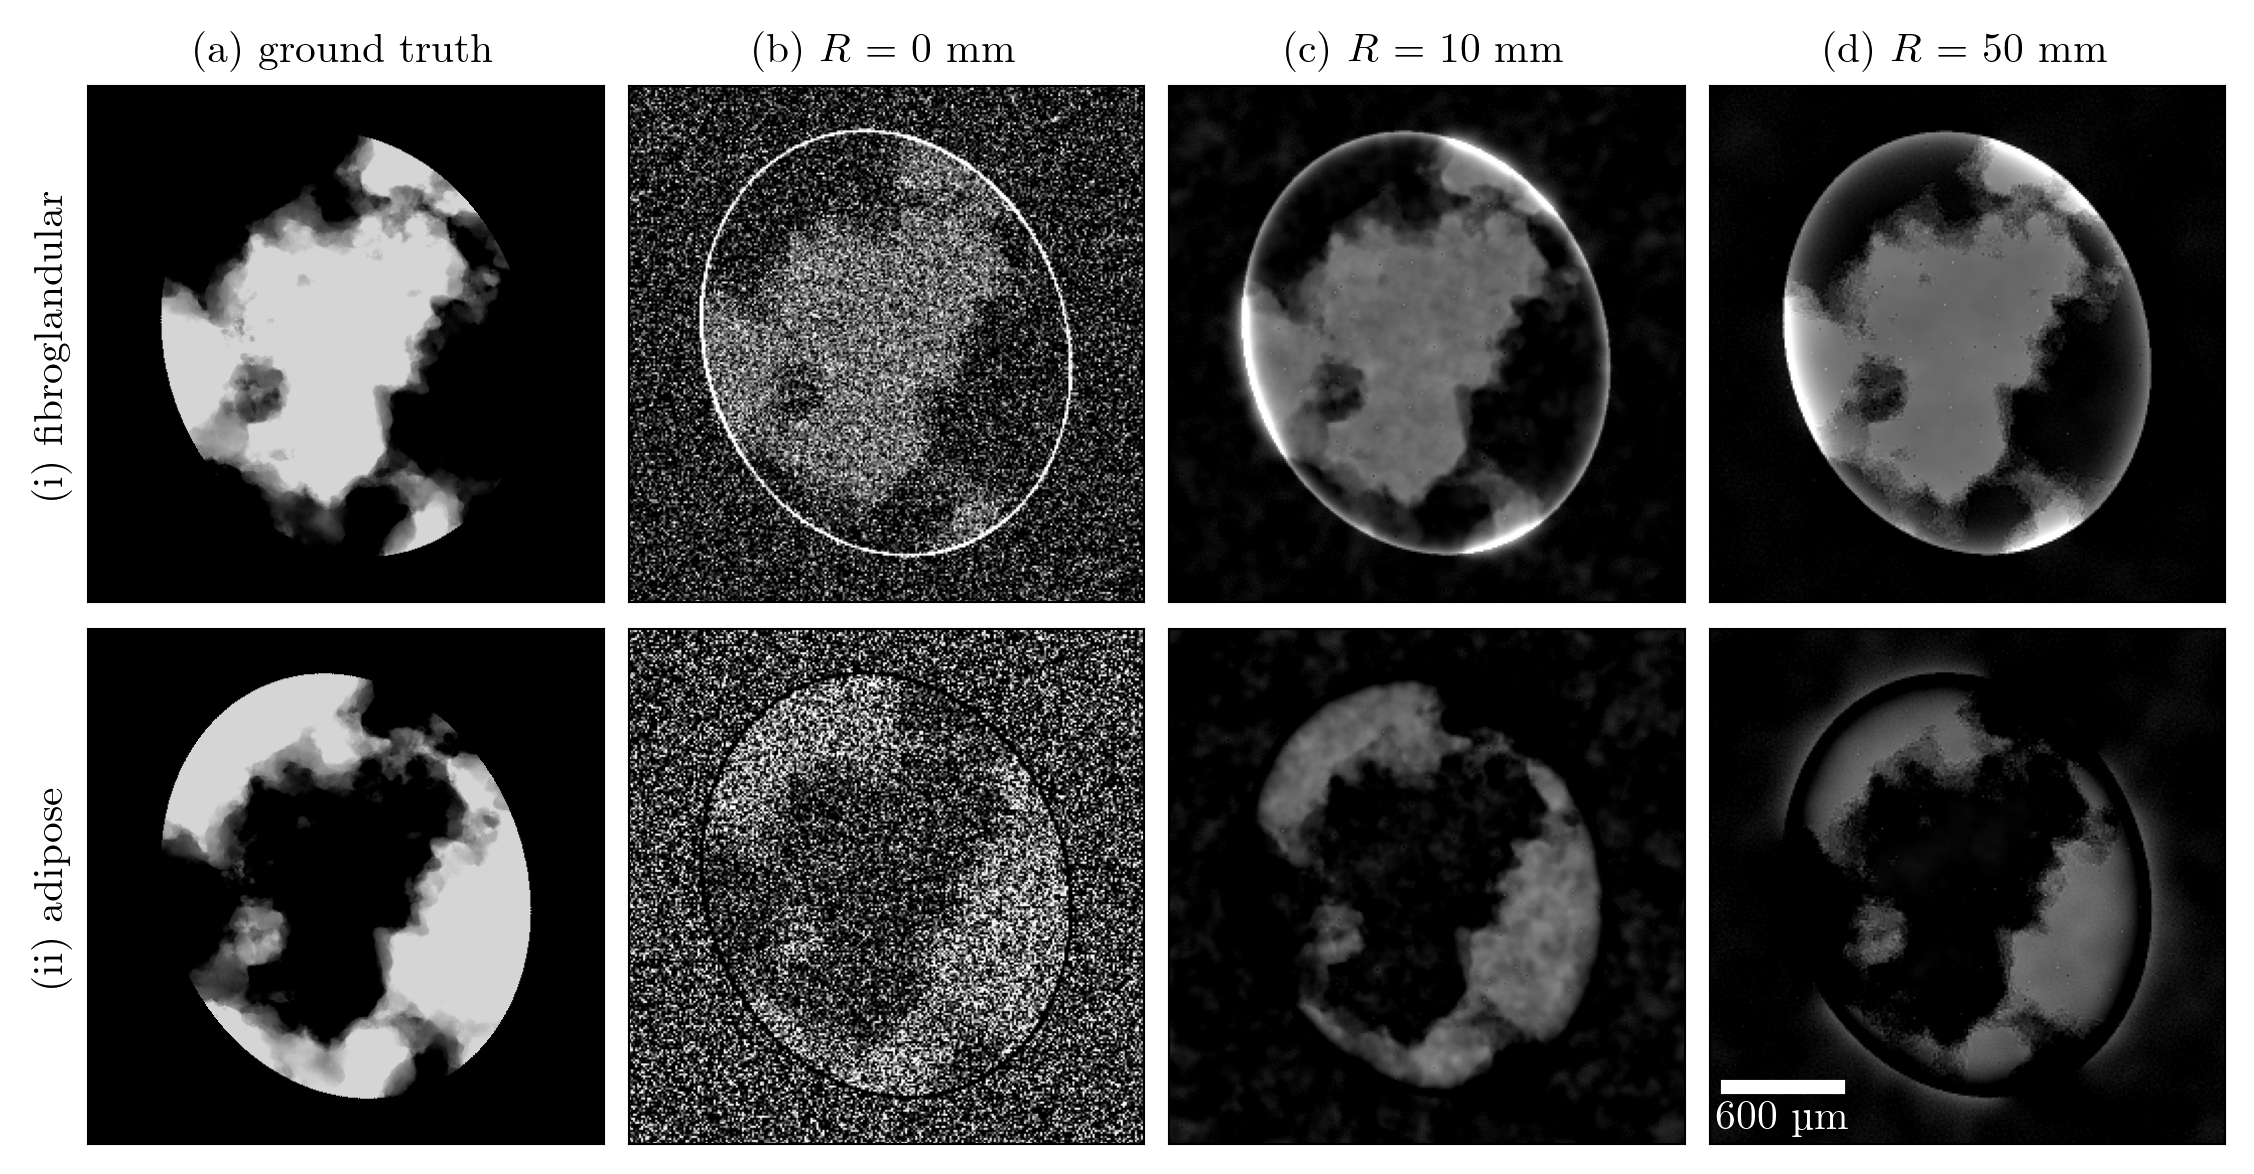

CPU times: user 14.3 s, sys: 290 ms, total: 14.6 s
Wall time: 2.17 s


In [192]:
%%time

abcde = 'abcde'

seed = 422

I0 = 1e2    
dx = 5e-6
N = 512
Nz = 50  
px, py = 0.35, 0.42 
energies = (20, 25)
det_dx = 10e-6

thickness = 3e-2
alpha = 5
mat_frac = 0.4

propdists = np.array([0, 10, 50]) * 1e-3


# make
np.random.seed(seed)
# vol = make_phantom(N, dx, alpha=alpha)[:Nz]
struct = np.zeros([N, N])
struct[tmap_ellipsoid(N, px*N, py*N, angle=20) > 1e-3] = 1

fig, axes = plt.subplots(2, 4, figsize=[7.4,3.8], layout='constrained')
kw = {'cmap':'gray', 'vmin':0, 'vmax':1.2*thickness}
for i, propdist in enumerate(propdists):
    results = run_material_decomposition(
        energies,
        R = propdist,
        det_dx = det_dx,
        thickness = TT,
        I0 = I0,
        mat_frac = mat_frac,
        vol = vol
    )
    ax = axes[:, i+1]
    ax[0].set_title(f'({abcde[i+1]}) $R$ = {propdist*1e3:.0f} mm')
    ax[0].imshow(results['bmis'][0], **kw)
    ax[1].imshow(results['bmis'][1], **kw)

axes[0,0].set_title('(a) ground truth')
axes[0,0].imshow(results['gt_bmi1'], **kw)
axes[1,0].imshow(results['gt_bmi2'], **kw)

fsz=10
axes[0,0].set_ylabel('(i) fibroglandular', fontsize=fsz)
axes[1,0].set_ylabel('(ii) adipose', fontsize=fsz)
for axi in axes.ravel():
    axi.set_xticks([])
    axi.set_yticks([])

add_scalebar(axes[-1,-1],  sz=0.1171, Nx=N, real_dx=det_dx*1e6, real_units='µm', color='w', sv=5)
plt.savefig('spie2026_mammo/fig3_examples.pdf', bbox_inches='tight')
plt.show()



